## 1. The algorithm, from audio input to audio output

This notebook simulates coherent quantum feedback acting on the STFT of an input signal: every frequency bin drives its own quantum delay line, and the output audio is decoded from the quantum state and from nothing else. A classical correlate, carrier-preserving coloured noise matched to the measured statistics of the quantum output, is rendered through the identical route for comparison.

**1. Frequency-bank representation.** The input is analysed by an STFT with a Hann window of $N$ samples and hop $H$ (currently $N{=}1024$, $H{=}256$ at $f_s{=}8000$). Each bin $k$ is handled by an independent quantum delay line, with one STFT frame per collision tick, so the loop delay is $\tau = d\,H/f_s$ seconds ($d{=}4$).

$$X(n,k)=\mathrm{STFT}\{x\},\qquad a(n)=|X(n,k)|,\qquad \varphi(n)=\angle X(n,k)$$

**2. Normalisation and companding.** Magnitudes are scaled by one global factor and companded by a power law that lifts weak bins into the responsive part of the Bloch sphere. The decode slope of this law is bounded, so trajectory noise is never expanded into magnitude spikes.

$$\tilde a(n)=\big(a(n)/\max|X|\big)^{\alpha},\qquad \alpha=0.8$$

**3. Encoding.** The probes entering the line carry the signal: magnitude as excitation, STFT phase as coherence phase. The system starts in the ground state and the line in vacuum; each bin's input is zero-padded by $d$ silent frames so the last injected probes still traverse the line.

$$|\psi_k(n)\rangle=\sqrt{1-\tilde a(n)}\;|0\rangle+\sqrt{\tilde a(n)}\;e^{i\varphi(n)}|1\rangle$$

**4. Free Hamiltonian, a per-bin carrier clock.** Every qubit of bin $k$'s register carries the same splitting, chosen so that the quantum phase advances each tick by the bin's own carrier rate; equal splittings keep the excitation-preserving exchange resonant, and $\sigma^z$ acting on vacuum does nothing. The rate is a single scalar per bin for the whole run, the energy-weighted circular mean of the input's frame-to-frame phase advance (the phase-vocoder instantaneous frequency):

$$H_0=\frac{\theta_k}{2}\sum_j\sigma^z_j,\qquad \theta_k=\theta^{\mathrm{bin}}_k+\angle z_k,\qquad \theta^{\mathrm{bin}}_k=2\pi f_k H/f_s$$

$$z_k=\sum_n |X(n{+}1,k)|^2\,e^{\,i\left(\Delta\varphi_{\mathrm{in}}(n,k)-\theta^{\mathrm{bin}}_k\right)},\qquad \Delta\varphi_{\mathrm{in}}(n,k)=\varphi_{\mathrm{in}}(n{+}1,k)-\varphi_{\mathrm{in}}(n,k)$$

An optional resonator acts on the system qubit alone (identity on every probe), so the full free Hamiltonian of bin $k$'s register reads

$$H_0=\frac{\theta_k}{2}\!\!\sum_{j\,\in\,\{S,\,D_0..D_{d-1},\,f\}}\!\!\sigma^z_j\;+\;\omega_s(k)\,\sigma^z_S,\qquad
\omega_s(k)=\Omega\,\frac{f_k}{f_s}\,g_z$$

The clock sum includes the system, so it is common to all qubits and cancels out of every splitting difference; the detuning is set by the resonator term alone.

Being system-only, it creates a splitting mismatch of $2\omega_s$ between system and probes (note there is no factor $\tfrac12$ on this term in the code), growing linearly with the bin frequency; the exchange transfer is suppressed by roughly $g^2/(g^2+\omega_s^2)$, which dries the channel towards the treble.

**5. Collision and coherent feedback.** Each tick applies $U=\exp[-i\Delta T(H_0+V)]$, with an excitation-preserving beamsplitter coupling to the fresh probe and, carrying the feedback phase, to the probe exiting after $d$ ticks ($\phi_{\mathrm{fb}}{=}\pi$, $g{=}0.25$, $g_z{=}0.3$). The beamsplitter annihilates $|00\rangle$, so silence stays silent by the physics itself; the $\sigma^z\sigma^z$ term is a QND transducer writing the system state onto the probe phase.

$$V = g\,(\sigma^x\sigma^x+\sigma^y\sigma^y)_{S,f}+g_z(\sigma^z\sigma^z)_{S,f}
-e^{-i\phi_{\mathrm{fb}}}\big[\,g\,(\sigma^x\sigma^x+\sigma^y\sigma^y)+g_z\,\sigma^z\sigma^z\,\big]_{S,D_0}$$

**6. Passive decode.** Before any measurement, the exiting probe's reduced state is read non-destructively: magnitude from its population through the inverse compander, phase from its coherence. The probe injected at frame $n$ exits after $d$ ticks; its decoded pair is assigned back to frame $n$, so index $n$ in every decoded matrix refers to the same audio time $nH/f_s$ as in the input.

$$a_{\mathrm{out}}(n)=\big(\langle 1|\rho_{D_0}|1\rangle\big)^{1/\alpha},\qquad
\varphi_{\mathrm{out}}(n)=\mathrm{atan2}\big(\langle\sigma^y\rangle,\langle\sigma^x\rangle\big)$$

**7. Projective measurement triggering a collapse chain.** The decoded probe is then measured projectively (basis $x$), with both outcome probabilities computed as $p_a=\mathrm{tr}(P_a\rho)$. The outcome collapses the entire register, the system now and, through the line, the probe a delay away; the sequence of collapses along the run constitutes one quantum trajectory, and sonifying trajectories rather than expectation values is what keeps uniquely quantum temporal correlations in the audio.

$$\rho\;\to\;P_a\,\rho\,P_a/\mathrm{tr}(P_a\rho),\qquad a\in\{0,1\}$$

**8. Trajectory renders.** The unconditional render (undep) averages the Bloch vectors of $n_{\mathrm{traj}}$ independent trajectories at each $(n,k)$ and decodes the average; the vector is averaged first and the angle taken last (currently $n_{\mathrm{traj}}{=}1$: a single trajectory). The conditional renders dep0 and dep1 are retrodictive: dep$_a$ keeps at frame $n$ only those trajectories whose measurement at frame $n{+}d$ gave outcome $a$, so the two renders re-paint the same buffered moment under the two possible futures. Where a class is empty the unconditional average is substituted.

$$b_{\mathrm{undep}}(n)=\big\langle(\sigma^x,\sigma^y,\mathrm{pop})(n)\big\rangle_{\mathrm{traj}},\qquad
b_a(n)=E\big[\,b(n)\mid \mathrm{outcome}(n{+}d)=a\,\big]$$

**9. Synthesis.** The audio is the inverse STFT of the decoded magnitude and phase matrices alone; the input is never mixed into the output.

$$y(t)=\mathrm{ISTFT}\big\{\,a_{\mathrm{out}}\cdot(\max|X|)\cdot e^{i\varphi_{\mathrm{out}}}\,\big\}$$

**10. Tick removal.** Decoded frames are discontinuous where trajectories collapse, and after overlap-add this can surface as clicks repeating at the hop period, meaning at one fixed offset $r=t\bmod H$ inside every frame. Outliers of the sample derivative,

$$\delta(t)=|y(t)-y(t{-}1)|,\qquad \delta(t)>5\max\!\big(\mathrm{med}\,\delta,\ 0.02\max\delta\big)$$

are histogrammed by offset; an offset counts as a tick offset when it collects clearly more of them than an even spread would give it — at least twice its uniform share, and never fewer than three. Those samples are replaced by a monotone cubic drawn through the surrounding untouched samples (a straight-line fill flattens part of each bass cycle at the frame seam and buzzes at the frame rate). If the outliers are spread across the frame instead of concentrated, or the repair would touch more than 10% of the audio, the render is left alone. Every run prints what was done and where.

**11. Playback.** Players are resampled to 44.1 kHz and embedded at 0.7 of full scale; saved wav files keep the native rate and true level.

**12. The classical correlate.** Carrier-preserving coloured noise: the rival keeps the input's own phases and magnitudes and adds $1/f^p$ noise whose depth, memory curve and modulation depth are copied from the measured quantum output, with all statistics energy-weighted so the match happens where the signal has energy. The full construction is summarised beside the first comparison (section 5), and the fit is plotted under every comparison.

$$\varphi_{\mathrm{cl}}=\varphi_{\mathrm{in}}+\mathrm{depth}\cdot\mathrm{pink}(p^*),\qquad
|X|_{\mathrm{cl}}=|X|\cdot\big(1+\mathrm{AM}\cdot\mathrm{pink}'(p^*)\big)$$

**13. Variants available in the code, inactive in this notebook.** Measurement basis $z$ (outcomes are actual excitation events) and none (deterministic channel, equal to non-selective measurement); the dep0/dep1 renders and their diagnostics; $n_{\mathrm{traj}}>1$ averaging; a grid-rate clock mode; soft and hard companding; the spin interaction $\sigma^x\sigma^x+\sigma^z\sigma^z$; per-bin frequency scaling of the couplings; the SMS route in which only the stochastic residual is processed and harmonic tracks stay clean; and the time-stretch renders of the demo notebook.

## 2. Parameters

In [1]:
import numpy as np, matplotlib.pyplot as plt, soundfile, os, time
from scipy.signal import resample_poly, spectrogram as scipy_spectrogram
from scipy.signal.windows import hann
from scipy.ndimage import binary_dilation
from IPython.display import Audio, display
import quantum_audio_master as qam
from dependent_trajectory import dependent_colour_transform_per_bin, _dependent_colour_kernel
%matplotlib inline
plt.rcParams['figure.dpi'] = 100

# step 1 - representation
FS_SIG = 8000                    # working rate (audio decimated to this)
N_AUD, H_AUD = 1024, 256         # STFT frame / hop, samples
N_SYN, H_SYN = N_AUD, H_AUD      # one STFT everywhere
FS_BASS = FS_SIG

# step 2 - companding
AMP_MODE, AMP_POW = 'power', 1   # enc a**p, dec p**(1/p)

# step 4 - free hamiltonian
CARRIER_CLOCK = True             # True: input IF | 'bin': grid rate | False: off
OMEGA_S_RES = 23                 # system-only resonator; detunes towards treble

# step 5 - collision + feedback
DELAY = 5                        # loop delay in frames (Hilbert dim 2^(d+2))
PHASE = np.pi                    # feedback phase
GAMMA_X = 0.75                   # system-line coupling (g in step 5); sets output magnitude
GAMMA_Z = 0.3                    # phase transducer (g_z in step 5)
INTERACTION = 'beamsplitter'

# steps 7-8 - measurement + renders
BASIS = 'x'                      # 'x' | 'z' | 'none'
N_TRAJ = 1
BASE_SEED = 12345
FAST = True

# inputs
AUDIO_PATH, TRIM_S, START_S = 'audio/nightfall.wav', 10.0, 504.0   # vibrato window
WC_PATH, WC_TRIM, WC_START, WC_FS = 'audio/windchimes.wav', 10.0, 48.0, 8000
GL_PATH, GL_TRIM, GL_START, GL_FS = 'audio/noecho.wav', 8.0, 0.0, 8000
NOTE_FREQS = [130.81, 164.81, 196]   # note 1 on the bin grid (clock control), notes 2-3 half-bin off
NOTE_DURATIONS = [0.3, 0.5, 0.7]
NOTE_DUR, SIL_DUR = 0.6, 0.5

# display / output
SPEC_FLOOR_DB = 60               # spectrum displays: peak .. peak - floor
OUT_DIR = 'output/dep_summary'; os.makedirs(OUT_DIR, exist_ok=True)
print(f'delay={DELAY} ({DELAY*H_SYN/FS_SIG*1e3:.0f} ms)  gx={GAMMA_X} gz={GAMMA_Z} basis={BASIS} '
      f'n_traj={N_TRAJ} amp_pow={AMP_POW} osr={OMEGA_S_RES} clock={CARRIER_CLOCK}')

delay=5 (160 ms)  gx=0.75 gz=0.3 basis=x n_traj=1 amp_pow=1 osr=23 clock=True


## 3. Pipeline helpers

`run_dep()` is the single route through the channel: STFT → per-bin dependent
transform (**all** bins) → inverse STFT (+ anti-tick surgery, §4).
`pink_rival()` builds the matched classical correlate from the *measured*
quantum output statistics.

In [2]:
from scipy.interpolate import PchipInterpolator
def stft_pair(x, N, H):
    mdB, ph = qam.STFT.stftAnal(x, hann(N), N, H)
    return 10**(mdB/20.0), ph

def istft(mag, phase, N, H):
    return qam.STFT.stftSynth(20*np.log10(np.maximum(mag, 1e-10)), phase, N, H)

def declick(y, H, k=5, dil=1, label=''):
    """Repair frame-periodic ticks. Refuses non-periodic noise; reports every event."""
    d = np.abs(np.diff(y, prepend=y[:1])); med = np.median(d) + 1e-12
    thr = k * max(med, 0.02 * float(d.max()))
    out = d > thr; pos = np.where(out)[0]
    if len(pos) == 0:
        print(f'  [declick {label}] inactive (no outlier samples)'); return y
    hist = np.bincount(pos % H, minlength=H); nfr = max(1, len(y)//H)
    uniform = len(pos) / H
    off = np.where(hist >= max(3, 0.03*nfr, 2.0*uniform))[0]
    if len(off) == 0 or len(off) > 0.25*H:
        print(f'  [declick {label}] {len(pos)} outliers spread over the frame -> '
              f'not frame-periodic, left untouched'); return y
    mask = binary_dilation(out & np.isin(np.arange(len(y)) % H, off), iterations=dil)
    if mask.mean() > 0.10:
        print(f'  [declick {label}] would touch {100*mask.mean():.1f}% of samples -> left untouched')
        return y
    idx = np.arange(len(y)); y = y.copy()
    y[mask] = PchipInterpolator(idx[~mask], y[~mask])(idx[mask])
    detail = ', '.join(f'offset {r} ({hist[r]} frames)' for r in off[:12])
    if len(off) > 12: detail += f', ... +{len(off)-12} more'
    print(f'  [declick {label}] interpolated {int(mask.sum())} samples '
          f'({100*mask.mean():.2f}%) at {len(off)} intra-frame offsets: {detail}')
    return y

def run_dep(x, fs, N, H, **kw):
    """The quantum channel. Returns the undep render + all decoded matrices."""
    in_mag, in_phase = stft_pair(x, N, H)
    nf, nb = in_mag.shape
    freq_bins = np.arange(nb) * fs / N
    p = dict(n_traj=N_TRAJ, base_seed=BASE_SEED, gamma_x=GAMMA_X, gamma_z=GAMMA_Z,
             interaction=INTERACTION, measurement_basis=BASIS, amp_mode=AMP_MODE,
             amp_pow=AMP_POW, omega_s_res=OMEGA_S_RES, fs=fs, fast=FAST, verbose=False,
             carrier_clock=CARRIER_CLOCK, stft_hop=H)
    delay = kw.pop('delay', DELAY); phase_fb = kw.pop('phase', PHASE)
    p.update(kw)
    t0 = time.time()
    om, oph, scale, diag = dependent_colour_transform_per_bin(
        in_mag, in_phase, freq_bins, np.arange(nb), delay, phase_fb, **p)
    print(f'  [transform] {nb} bins x {nf} frames, n_traj={p["n_traj"]}, '
          f'basis={p["measurement_basis"]}: {time.time()-t0:.1f}s')
    om_real = om['uncond'] * scale[None, :]
    y = declick(istft(om_real, oph['uncond'], N, H), H, label='undep')
    return dict(y=y, x=x, in_mag=in_mag, in_phase=in_phase, out_mag=om,
                out_phase=oph, scale=scale, diag=diag, freq_bins=freq_bins,
                N=N, H=H, fs=fs)

# ── classical rival: carrier-preserving circular-ACF-matched pink noise ──
def pink_field(nf, nb, p, seed=0):
    rng = np.random.default_rng(seed); w = rng.standard_normal((nf, nb))
    f = np.fft.rfftfreq(nf).copy(); f[0] = f[1] if len(f) > 1 else 1.0
    x = np.fft.irfft(np.fft.rfft(w, axis=0) / (f[:, None]**(p/2)), n=nf, axis=0)
    return (x - x.mean(0)) / (x.std(0) + 1e-9)

def pink_rival(r, seed=0):
    """Carrier-preserving pink correlate (definition above)."""
    in_mag, in_phase = r['in_mag'], r['in_phase']
    out_ph = r['out_phase']['uncond']
    out_m  = r['out_mag']['uncond'] * r['scale'][None, :]
    nf, nb = in_mag.shape
    dev_q = np.angle(np.exp(1j*(out_ph - in_phase)))               # wrap-safe deviation
    st_q  = np.angle(np.exp(1j*np.diff(dev_q, axis=0)))
    W = in_mag**2                   # energy weights: match where sound is
    depth = float(np.sqrt((W*dev_q**2).sum()/(W.sum()+1e-30)))
    step = float(np.sqrt((st_q**2).mean()))
    L = min(25, nf - 1)             # fit the full ACF curve, not only lag 1
    def _cacf(f):
        out = np.empty(L); out[0] = 1.0
        for l in range(1, L):
            wl = W[l:]*W[:-l]
            out[l] = float((wl*np.cos(f[l:] - f[:-l])).sum()/(wl.sum()+1e-30))
        return out
    target = _cacf(dev_q)
    grid = np.linspace(0.3, 6.0, 20)
    def _cost(p):
        return float(np.sum((_cacf(depth * pink_field(nf, nb, p, seed+3)) - target)**2))
    P = float(min(grid, key=_cost))
    pink_dev = depth * pink_field(nf, nb, P, seed+7)
    cl_phase = in_phase + pink_dev
    en = in_mag > 0.1*in_mag.max()
    am = (float(np.clip(np.std((out_m/np.maximum(in_mag, 1e-12))[en] - 1.0), 0.05, 1.0))
          if en.any() else 0.3)
    cl_mag = np.clip(in_mag*(1.0 + am*pink_field(nf, nb, P, seed+8)), 0.0, None)
    print(f'  [pink] dev depth={depth:.2f} rad, curve-fit p={P:.2f} '
          f'(ACF residual {np.sqrt(_cost(P)/L):.3f}), AM depth={am:.2f}')
    y = declick(istft(cl_mag, cl_phase, r['N'], r['H']), r['H'], label='pink')
    return dict(y=y, p=P, depth=depth, am=am, dev=pink_dev, dev_q=dev_q)

# ── presentation ──
def play(y, fs, label=''):
    yr = resample_poly(y, 44100, fs)
    pk = np.max(np.abs(yr)) + 1e-12
    yr = yr * 0.7 / pk          # playback-normalised with real headroom
    print(f'  {label} (true peak {np.max(np.abs(y)):.4f}, playback normalised)')
    # normalize=False: stop IPython.Audio re-scaling to 0 dBFS — full-scale samples
    # crackle in playback chains (worst on whichever note holds the file's max sample)
    display(Audio(yr, rate=44100, normalize=False))

def show_compare(title, entries, fs, fmax=None):
    """entries = [(label, y, color)] -> waveform row + spectrogram row."""
    n = len(entries); fmax = fmax or fs/2
    fig, ax = plt.subplots(2, n, figsize=(4.6*n, 5.6), squeeze=False)
    specs = []
    for lab, y, col in entries:
        f, t, S = scipy_spectrogram(y, fs, window=hann(N_SYN), nperseg=N_SYN,
                                    noverlap=N_SYN - H_SYN, detrend=False)
        specs.append((f, t, 10*np.log10(S + 1e-20)))
    vmax = max(L.max() for _, _, L in specs)
    for c, (lab, y, col) in enumerate(entries):
        ax[0][c].plot(np.arange(len(y))/fs, y, col, lw=0.6)
        ax[0][c].set_title(f'{lab} — waveform  (peak {np.max(np.abs(y)):.3g})', fontsize=9)
        ax[0][c].grid(alpha=.3); ax[0][c].set_xlabel('s')
        f, t, Ldb = specs[c]
        ax[1][c].pcolormesh(t, f, Ldb, shading='auto', cmap='magma',
                            vmin=vmax-SPEC_FLOOR_DB, vmax=vmax)
        ax[1][c].set_title(f'{lab} — spectrogram', fontsize=9)
        ax[1][c].set_ylim(0, fmax); ax[1][c].set_ylabel('Hz'); ax[1][c].set_xlabel('s')
    fig.suptitle(title, fontweight='bold', fontsize=15)
    plt.tight_layout(); plt.show()

def output_phase_acf_plot(y_q, y_pk, N, H, max_lag=30):
    """Utility (small): the 6a-style OUTPUT verification — re-analyse the two
    RENDERED audios with the same STFT and compare the phase ACF of the actual
    sound. Checks that the statistical match survives synthesis."""
    def pacf(y):
        ph = qam.STFT.stftAnal(y, hann(N), N, H)[1]
        x = ph - ph.mean(0); v = (x**2).mean(0); v = np.where(v < 1e-12, np.nan, v)
        nf = ph.shape[0]; L = min(max_lag, nf // 2)
        return np.array([np.nanmean((x[:nf-l]*x[l:]).mean(0)/v) for l in range(L)])
    def tau(a):
        b = np.where(a < 1/np.e)[0]; return int(b[0]) if len(b) else len(a)
    aq, ap = pacf(y_q), pacf(y_pk)
    plt.figure(figsize=(4.6, 1.9))
    plt.plot(aq, 'r-', lw=1.4, label=f'quantum out ($\\tau$={tau(aq)})')
    plt.plot(ap, '--', color='#E91E63', lw=1.1, label=f'pink out ($\\tau$={tau(ap)})')
    plt.axhline(1/np.e, color='gray', ls=':', lw=0.7)
    plt.xlabel('lag (frames)', fontsize=7); plt.ylabel('phase ACF', fontsize=7)
    plt.title('utility: OUTPUT phase ACF of the rendered audio', fontsize=7.5)
    plt.legend(fontsize=6.5); plt.grid(alpha=.3)
    plt.xticks(fontsize=6.5); plt.yticks(fontsize=6.5)
    plt.tight_layout(); plt.show()

def dev_acf_plot(pk, max_lag=40):
    """Circular ACF of the phase-deviation fields: quantum vs matched pink."""
    def cacf(d):
        L = min(max_lag, d.shape[0]-1); out = np.empty(L); out[0] = 1.0
        for l in range(1, L):
            out[l] = float(np.cos(d[l:] - d[:-l]).mean())
        return out
    q, p = cacf(pk['dev_q']), cacf(pk['dev'])
    plt.figure(figsize=(8, 3.2))
    plt.plot(q, 'r-', lw=2.5, label='quantum deviation')
    plt.plot(p, '--', color='#E91E63', lw=1.8, label=f"matched pink p={pk['p']:.2f}")
    plt.axhline(1/np.e, color='gray', ls=':', lw=1); plt.axhline(0, color='gray', lw=.5)
    plt.xlabel('lag (frames)'); plt.ylabel('circular ACF')
    plt.title('deviation-field memory: quantum vs circular-matched pink')
    plt.legend(); plt.grid(alpha=.3); plt.tight_layout(); plt.show()

from scipy.signal import decimate as _decimate

def load_decimated(path, start_s, trim_s, target_fs):
    """Mono, peak-normalise, trim, 0.2 s edge fades, FIR zero-phase decimate."""
    x, sr = soundfile.read(path, dtype='float64')
    if x.ndim > 1: x = x.mean(axis=1)
    x = x[int(start_s*sr):int((start_s+trim_s)*sr)]
    x = x / max(np.max(np.abs(x)), 1e-9)
    nf = int(0.2*sr)
    x[:nf] *= np.linspace(0, 1, nf); x[-nf:] *= np.linspace(1, 0, nf)
    D = max(1, int(round(sr/target_fs)))
    if D > 1: x = _decimate(x, D, ftype='fir', zero_phase=True)
    fs2 = sr // D
    print(f'{path}: {trim_s}s from t={start_s}s, decimated x{D}: {sr} -> {fs2} Hz, {len(x)} samples')
    return x, fs2

print('helpers loaded')

helpers loaded


## 4. Impulse response of the quantum kernel

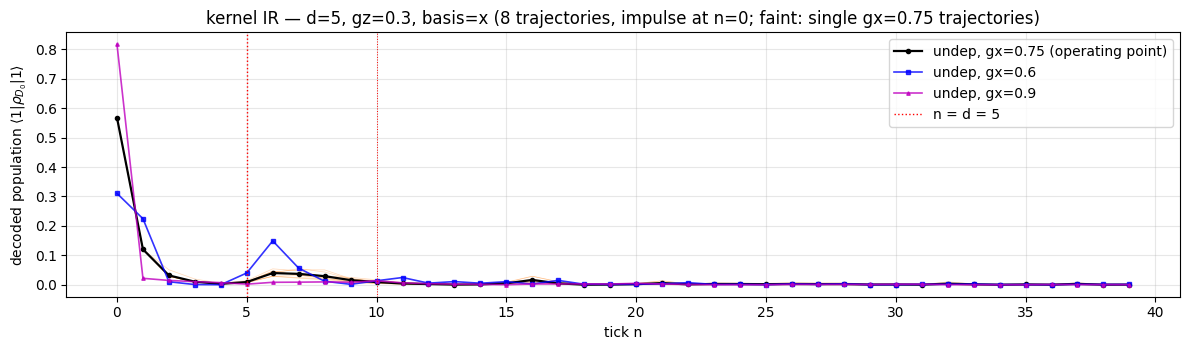

In [3]:
def kernel_ir(delay=DELAY, gx=GAMMA_X, gz=GAMMA_Z, phase=PHASE, basis=BASIS,
              steps=40, n_traj=8, seed=BASE_SEED, omega_s=0.0):
    amps = np.zeros(steps); amps[0] = 1.0
    phs = np.zeros(steps)
    POP = np.empty((n_traj, steps))
    for t in range(n_traj):
        _, _, pop, _ = _dependent_colour_kernel(
            amps, phs, gx, gz, omega_s, 0.0, 0.0, 0.0, delay, phase, 1.0,
            basis, 'Pur.Deph', seed + t, interaction=INTERACTION, fast=FAST)
        POP[t] = pop
    return POP

POP  = kernel_ir()                     # operating point
POP6 = kernel_ir(gx=0.6)
POP8 = kernel_ir(gx=0.9)

plt.figure(figsize=(12, 3.6))
for t in range(POP.shape[0]):
    plt.plot(POP[t], color='tab:orange', lw=0.5, alpha=0.3)
plt.plot(POP.mean(0),  'k-o', lw=1.6, ms=3,   label=f'undep, gx={GAMMA_X} (operating point)')
plt.plot(POP6.mean(0), 'b-s', lw=1.2, ms=2.5, alpha=0.8, label='undep, gx=0.6')
plt.plot(POP8.mean(0), 'm-^', lw=1.2, ms=2.5, alpha=0.8, label='undep, gx=0.9')
plt.axvline(DELAY, color='r', ls=':', lw=1, label=f'n = d = {DELAY}')
plt.axvline(2*DELAY, color='r', ls=':', lw=0.7)
plt.xlabel('tick n'); plt.ylabel(r'decoded population $\langle 1|\rho_{D_0}|1\rangle$')
plt.title(f'kernel IR — d={DELAY}, gz={GAMMA_Z}, basis={BASIS} '
          f'(8 trajectories, impulse at n=0; faint: single gx={GAMMA_X} trajectories)')
plt.legend(); plt.grid(alpha=.3); plt.tight_layout(); plt.show()

## 5. Impulse through the full chain — undep vs pink

### The classical correlate

Each comparison builds its rival from the measured quantum output. The phase the channel wrote, dev = ∠e^{i(φ_out−φ_in)}, is summarised by its energy-weighted depth and memory curve C(ℓ) (step 12 of section 1); a 1/f^p noise field with that depth and a fitted exponent p* rides the input carrier instead of it, and an independent field of the same exponent modulates the magnitudes at the measured AM depth.

The plot titled *deviation-field memory* under each comparison shows the fit directly: the solid red curve is the quantum C(ℓ), the dashed pink curve is C_pink(ℓ; p*), and the `[pink]` line prints depth, p* and the fit residual. Matched: carrier, phase depth, phase memory, AM depth. Not matched: amplitude memory, amplitude–phase correlation, the quantum noise floor.

  [transform] 513 bins x 44 frames, n_traj=1, basis=x: 57.3s
  [declick undep] interpolated 46 samples (0.41%) at 7 intra-frame offsets: offset 0 (3 frames), offset 62 (3 frames), offset 63 (3 frames), offset 64 (4 frames), offset 65 (4 frames), offset 66 (3 frames), offset 207 (3 frames)
  [pink] dev depth=1.84 rad, curve-fit p=2.10 (ACF residual 0.163), AM depth=0.31
  [declick pink] 827 outliers spread over the frame -> not frame-periodic, left untouched


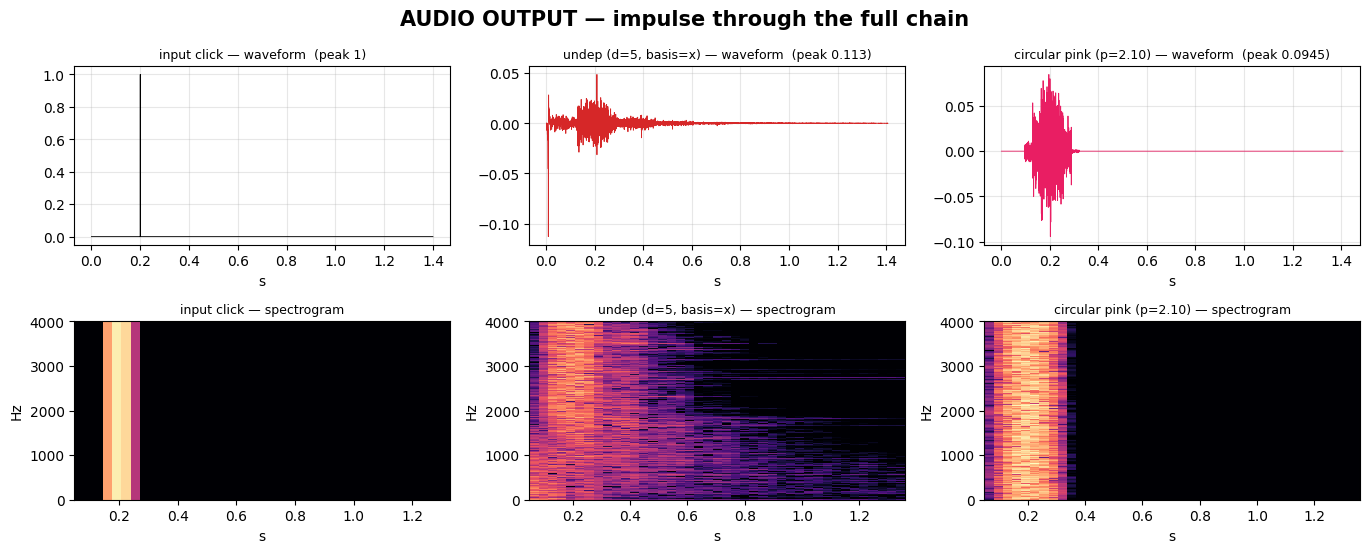

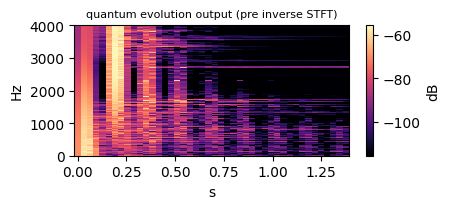

  undep IR (true peak 0.1129, playback normalised)


  pink IR (true peak 0.0945, playback normalised)


In [4]:
click = np.zeros(int(1.4*FS_SIG)); click[int(0.2*FS_SIG)] = 1.0
r_ir = run_dep(click, FS_SIG, N_SYN, H_SYN)
pk_ir = pink_rival(r_ir, seed=1)
show_compare('AUDIO OUTPUT — impulse through the full chain', [
    ('input click', click, 'k'),
    (f'undep (d={DELAY}, basis={BASIS})', r_ir['y'], 'tab:red'),
    (f"circular pink (p={pk_ir['p']:.2f})", pk_ir['y'], '#E91E63')], FS_SIG)
# a single-sample click carries little energy per bin; panels autoscale, play() normalises

# quantum evolution output, before the inverse STFT
t_fr = np.arange(r_ir['in_mag'].shape[0]) * H_SYN / FS_SIG
fbins = r_ir['freq_bins']
M = r_ir['out_mag']['uncond'] * r_ir['scale'][None, :]
Mdb = 20*np.log10(np.maximum(M, 1e-16)); vmax = Mdb.max()
fig, ax = plt.subplots(figsize=(4.6, 2.2))
im = ax.pcolormesh(t_fr, fbins, Mdb.T, shading='auto', cmap='magma',
                   vmin=vmax-SPEC_FLOOR_DB, vmax=vmax)
ax.set_title('quantum evolution output (pre inverse STFT)',
             fontsize=8)
ax.set_xlabel('s'); ax.set_ylabel('Hz'); ax.set_ylim(0, FS_SIG/2)
plt.colorbar(im, ax=ax, label='dB')
plt.tight_layout(); plt.show()

play(r_ir['y'], FS_SIG, 'undep IR'); play(pk_ir['y'], FS_SIG, 'pink IR')

## 6. Bass notes — undep vs pink

Note 1 sits exactly on the bin grid; notes 2 and 3 are half a bin off. Below the comparison, the decoded amplitude map (channel output before synthesis) next to the analysis magnitudes.

  [transform] 513 bins x 94 frames, n_traj=1, basis=x: 29.0s
  [declick undep] interpolated 108 samples (0.45%) at 1 intra-frame offsets: offset 0 (36 frames)
  [pink] dev depth=2.06 rad, curve-fit p=1.20 (ACF residual 0.277), AM depth=0.98
  [declick pink] interpolated 99 samples (0.41%) at 1 intra-frame offsets: offset 0 (33 frames)


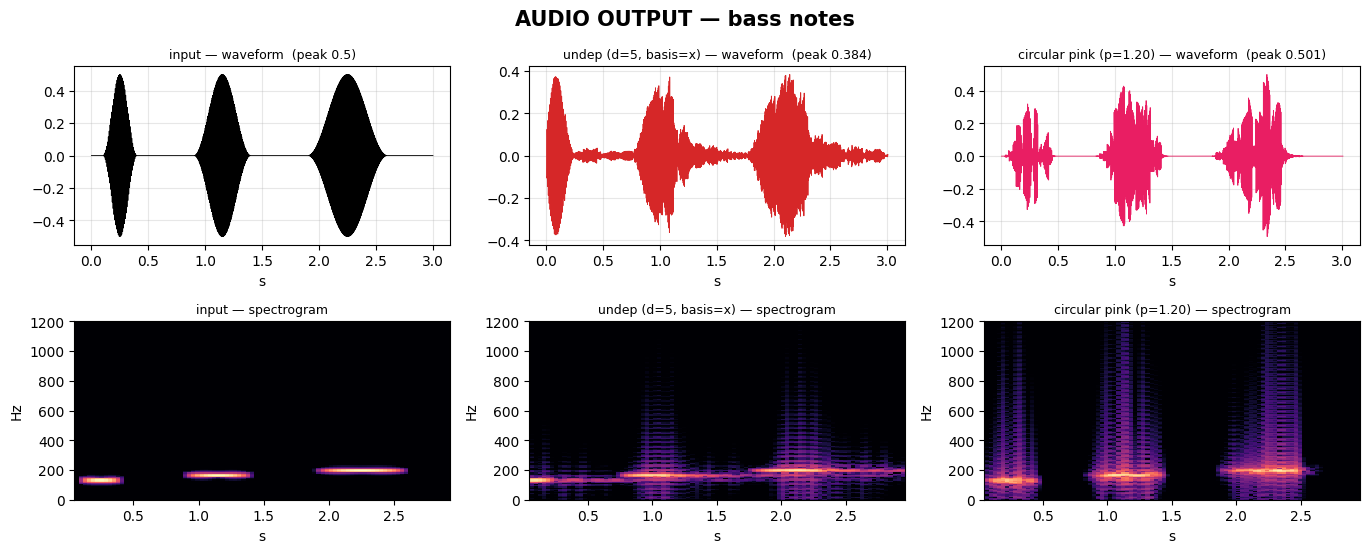

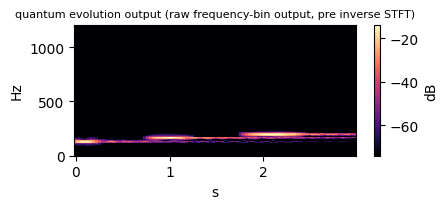

  input (true peak 0.4999, playback normalised)


  undep (true peak 0.3840, playback normalised)


  pink (true peak 0.5006, playback normalised)


In [5]:
def make_base_notes(freqs=NOTE_FREQS, note_dur=NOTE_DURATIONS, silence_dur=SIL_DUR, fs=FS_BASS):
    seg = [np.zeros(int(0.1*fs))]   # 0.1 s leading silence (initial-state control)
    for i, f in enumerate(freqs):
        t = np.arange(int(note_dur[i]*fs))/fs
        env = 0.5*(1 - np.cos(2*np.pi*t/note_dur[i]))
        seg.append(0.5*np.sin(2*np.pi*f*t)*env)
        if i < len(freqs)-1: seg.append(np.zeros(int(silence_dur*fs)))
    seg.append(np.zeros(int(0.4*fs)))
    return np.concatenate(seg)

bass = make_base_notes()
r_bass = run_dep(bass, FS_BASS, N_SYN, H_SYN)
pk_bass = pink_rival(r_bass, seed=2)
show_compare('AUDIO OUTPUT — bass notes', [
    ('input', bass, 'k'),
    (f'undep (d={DELAY}, basis={BASIS})', r_bass['y'], 'tab:red'),
    (f"circular pink (p={pk_bass['p']:.2f})", pk_bass['y'], '#E91E63')], FS_BASS, fmax=1200)

# quantum evolution output, before the inverse STFT (the input's STFT view is
# already the spectrogram in the row above)
t_fr = np.arange(r_bass['in_mag'].shape[0]) * H_SYN / FS_BASS
fbins = r_bass['freq_bins']
M = r_bass['out_mag']['uncond'] * r_bass['scale'][None, :]
Mdb = 20*np.log10(np.maximum(M, 1e-16)); vmax = Mdb.max()
fig, ax = plt.subplots(figsize=(4.6, 2.2))
im = ax.pcolormesh(t_fr, fbins, Mdb.T, shading='auto', cmap='magma',
                   vmin=vmax-SPEC_FLOOR_DB, vmax=vmax)
ax.set_title('quantum evolution output (raw frequency-bin output, pre inverse STFT)',
             fontsize=8)
ax.set_xlabel('s'); ax.set_ylabel('Hz'); ax.set_ylim(0, 1200)
plt.colorbar(im, ax=ax, label='dB')
plt.tight_layout(); plt.show()

play(bass, FS_BASS, 'input'); play(r_bass['y'], FS_BASS, 'undep'); play(pk_bass['y'], FS_BASS, 'pink')

## 7. Audio — no-echo

audio/noecho.wav: 8.0s from t=0.0s, decimated x6: 44100 -> 7350 Hz, 58800 samples
  [transform] 513 bins x 230 frames, n_traj=1, basis=x: 309.6s
  [declick undep] interpolated 132 samples (0.22%) at 2 intra-frame offsets: offset 44 (24 frames), offset 144 (20 frames)
  [pink] dev depth=1.96 rad, curve-fit p=1.50 (ACF residual 0.170), AM depth=0.62
  [declick pink] 5647 outliers spread over the frame -> not frame-periodic, left untouched


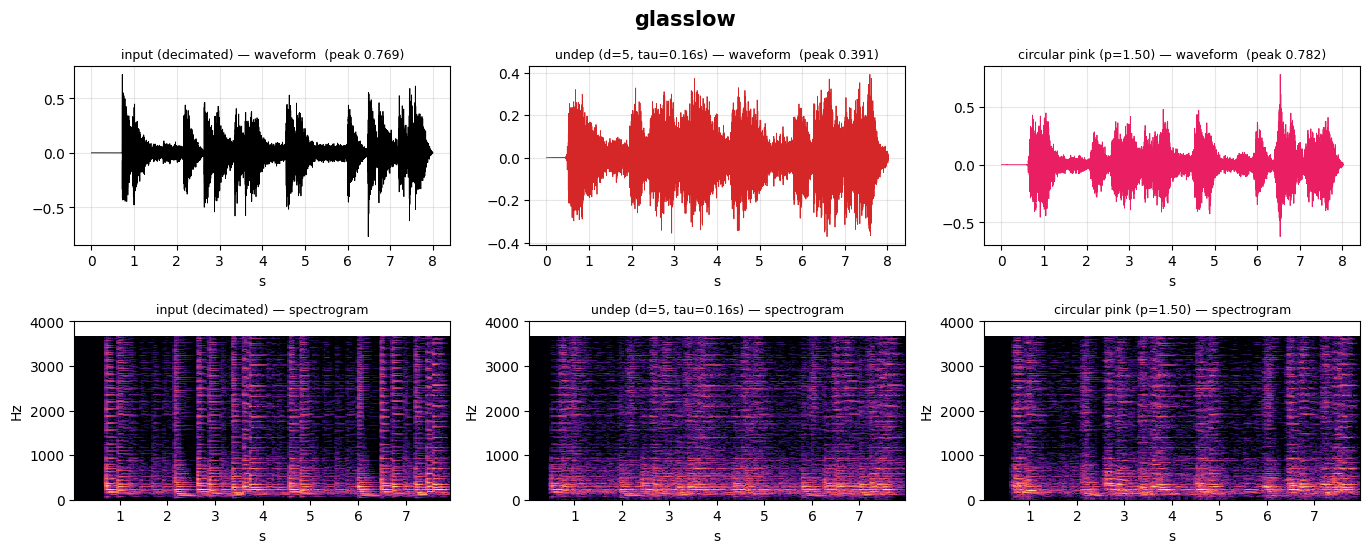

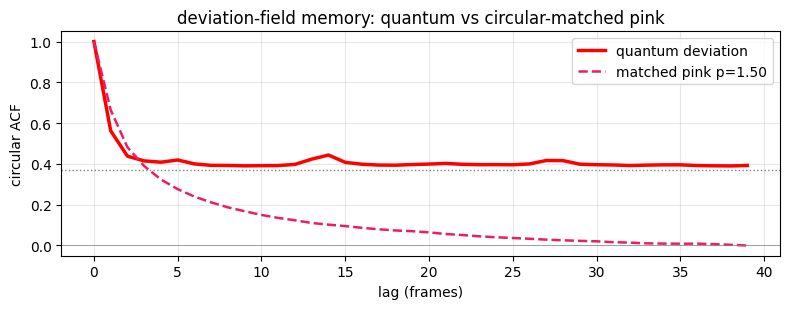

  input (true peak 0.7691, playback normalised)


  undep (true peak 0.3913, playback normalised)


  pink (true peak 0.7820, playback normalised)


saved to output/dep_summary


In [6]:
gl, fs_gl = load_decimated(GL_PATH, GL_START, GL_TRIM, GL_FS)
r_gl = run_dep(gl, fs_gl, N_AUD, H_AUD)
pk_gl = pink_rival(r_gl, seed=4)
show_compare('glasslow', [
    ('input (decimated)', gl, 'k'),
    (f'undep (d={DELAY}, tau={DELAY*H_AUD/GL_FS:.2f}s)', r_gl['y'], 'tab:red'),
    (f"circular pink (p={pk_gl['p']:.2f})", pk_gl['y'], '#E91E63')], fs_gl, fmax=4000)
dev_acf_plot(pk_gl)
play(gl, fs_gl, 'input'); play(r_gl['y'], fs_gl, 'undep'); play(pk_gl['y'], fs_gl, 'pink')
for nm, y in [('input', gl), ('undep', r_gl['y']), ('pink', pk_gl['y'])]:
    soundfile.write(os.path.join(OUT_DIR, f'no echo{nm}.wav'), y.astype(np.float32), fs_gl)
print('saved to', OUT_DIR)

## 8. Audio — vibrato 

A moving bass line with per-note vibrato; the strongest wobble (~90 cents at 4.9 Hz on ~90 Hz) sits a couple of seconds in.

In [ ]:
audio, _fs_a = load_decimated(AUDIO_PATH, START_S, TRIM_S, FS_SIG)

r_aud = run_dep(audio, FS_SIG, N_AUD, H_AUD)
pk_aud = pink_rival(r_aud, seed=3)
show_compare('Audio input', [
    ('input (decimated)', audio, 'k'),
    (f'undep (d={DELAY}, tau={DELAY*H_AUD/FS_SIG:.2f}s)', r_aud['y'], 'tab:red'),
    (f"circular pink (p={pk_aud['p']:.2f})", pk_aud['y'], '#E91E63')], FS_SIG, fmax=4000)
dev_acf_plot(pk_aud)
play(audio, FS_SIG, 'input'); play(r_aud['y'], FS_SIG, 'undep'); play(pk_aud['y'], FS_SIG, 'pink')
for nm, y in [('input', audio), ('undep', r_aud['y']), ('pink', pk_aud['y'])]:
    soundfile.write(os.path.join(OUT_DIR, f'audio_{nm}.wav'), y.astype(np.float32), FS_SIG)
print('saved to', OUT_DIR)

audio/nightfall.wav: 10.0s from t=504.0s, decimated x6: 48000 -> 8000 Hz, 80000 samples


## 9. Audio — transients

In [ ]:
wc, fs_wc = load_decimated(WC_PATH, WC_START, WC_TRIM, WC_FS)
r_wc = run_dep(wc, fs_wc, N_AUD, H_AUD)
pk_wc = pink_rival(r_wc, seed=4)
show_compare('Windchimes', [
    ('input (decimated)', wc, 'k'),
    (f'undep (d={DELAY}, tau={DELAY*H_AUD/WC_FS:.2f}s)', r_wc['y'], 'tab:red'),
    (f"circular pink (p={pk_wc['p']:.2f})", pk_wc['y'], '#E91E63')], fs_wc, fmax=4000)
dev_acf_plot(pk_wc)
play(wc, fs_wc, 'input'); play(r_wc['y'], fs_wc, 'undep'); play(pk_wc['y'], fs_wc, 'pink')
for nm, y in [('input', wc), ('undep', r_wc['y']), ('pink', pk_wc['y'])]:
    soundfile.write(os.path.join(OUT_DIR, f'windchimes_{nm}.wav'), y.astype(np.float32), fs_wc)
print('saved to', OUT_DIR)

## 10. Delay sweep — quantum evolution output (impulse input)

In [ ]:
# full-chain response of the impulse at four delays, pre inverse STFT
DELAYS = [2, 3, 5, 6]
click_s = np.zeros(int(1.4*FS_SIG)); click_s[int(0.2*FS_SIG)] = 1.0
maps = []
for dd in DELAYS:
    r = run_dep(click_s, FS_SIG, N_SYN, H_SYN, delay=dd)
    M = r['out_mag']['uncond'] * r['scale'][None, :]
    maps.append((dd, 20*np.log10(np.maximum(M, 1e-16)), r['freq_bins']))
vmax = max(Mdb.max() for _, Mdb, _ in maps)
fig, ax = plt.subplots(1, len(DELAYS), figsize=(15, 3.2), sharey=True)
for a, (dd, Mdb, fb) in zip(ax, maps):
    t_fr = np.arange(Mdb.shape[0]) * H_SYN / FS_SIG
    a.pcolormesh(t_fr, fb, Mdb.T, shading='auto', cmap='magma',
                 vmin=vmax-SPEC_FLOOR_DB, vmax=vmax)
    a.set_title(f'd={dd}   tau={dd*H_SYN/FS_SIG*1e3:.0f} ms', fontsize=9); a.set_xlabel('s')
ax[0].set_ylabel('Hz')
fig.suptitle('quantum evolution output (pre inverse STFT) — delay sweep', fontsize=11)
plt.tight_layout(); plt.show()

## 11. Coupling sweep — quantum evolution output (impulse input)

In [ ]:
# full-chain response of the impulse across both couplings, pre inverse STFT
GXS = [0.25, 0.5, 0.75, 1.0]      # row 1: exchange sweep (gz = GAMMA_Z)
GZS = [0.0, 0.3, 0.6, 1.5]        # row 2: transducer sweep (gx = GAMMA_X); ~1.5 is the dead spot
rows = [[('gx', g, dict(gamma_x=g)) for g in GXS],
        [('gz', g, dict(gamma_z=g)) for g in GZS]]
maps = []
for row in rows:
    maps.append([])
    for name, g, kw in row:
        r = run_dep(click_s, FS_SIG, N_SYN, H_SYN, **kw)
        M = r['out_mag']['uncond'] * r['scale'][None, :]
        maps[-1].append((name, g, 20*np.log10(np.maximum(M, 1e-16)), r['freq_bins']))
vmax = max(Mdb.max() for row in maps for _, _, Mdb, _ in row)
fig, ax = plt.subplots(2, 4, figsize=(15, 6.0), sharey=True)
for ai, row in zip(ax, maps):
    for a, (name, g, Mdb, fb) in zip(ai, row):
        t_fr = np.arange(Mdb.shape[0]) * H_SYN / FS_SIG
        a.pcolormesh(t_fr, fb, Mdb.T, shading='auto', cmap='magma',
                     vmin=vmax-SPEC_FLOOR_DB, vmax=vmax)
        a.set_title(f'{name}={g}', fontsize=9)
ax[0][0].set_ylabel(f'gx sweep  (gz={GAMMA_Z})\nHz'); ax[1][0].set_ylabel(f'gz sweep  (gx={GAMMA_X})\nHz')
for a in ax[1]: a.set_xlabel('s')
fig.suptitle('quantum evolution output (pre inverse STFT) — coupling sweeps', fontsize=11)
plt.tight_layout(); plt.show()

## 12. Measurement basis — x vs z, on the bass notes

In [ ]:
r_bass_z = run_dep(bass, FS_BASS, N_SYN, H_SYN, measurement_basis='z')
show_compare('measurement basis', [
    ('input', bass, 'k'),
    ("basis='x'", r_bass['y'], 'tab:red'),
    ("basis='z'", r_bass_z['y'], 'tab:brown')], FS_BASS, fmax=1200)
play(r_bass['y'], FS_BASS, "basis='x'"); play(r_bass_z['y'], FS_BASS, "basis='z'")

## 13. Resonator sweep, on the bass notes

In [ ]:
OSR = [0.0, 10, 23, 100.0]
renders = {}
for o in OSR:
    renders[o] = r_bass['y'] if o == OMEGA_S_RES else run_dep(bass, FS_BASS, N_SYN, H_SYN, omega_s_res=o)['y']
show_compare('OMEGA_S_RES sweep', [('input', bass, 'k')] +
             [(f'osr={o}', renders[o], 'tab:red') for o in OSR], FS_BASS, fmax=1200)
for o in OSR: play(renders[o], FS_BASS, f'osr={o}')

## 14. Signal processing, explicit

The classical stages around the channel, each shown by switching it on and off over the bass notes.

In [ ]:
# 14a. tick removal on vs off (no new simulation)
om_real = r_bass['out_mag']['uncond'] * r_bass['scale'][None, :]
y_raw = istft(om_real, r_bass['out_phase']['uncond'], N_SYN, H_SYN)
y_dc = declick(y_raw.copy(), H_SYN, label='13a')
fig, ax = plt.subplots(2, 1, figsize=(12, 4), sharex=True)
for a, (y, ttl) in zip(ax, [(y_raw, 'raw synthesis'), (y_dc, 'after tick removal')]):
    a.plot(np.arange(len(y))/FS_BASS, y, lw=0.5); a.set_title(ttl, fontsize=9); a.grid(alpha=.3)
plt.tight_layout(); plt.show()
play(y_raw, FS_BASS, 'raw'); play(y_dc, FS_BASS, 'declicked')

In [ ]:
# 14b. companding: current alpha vs 0.4
a_ax = np.linspace(0, 1, 300)
fig, ax = plt.subplots(1, 2, figsize=(9, 3))
for al in (AMP_POW, 0.4):
    ax[0].plot(a_ax, a_ax**al, label=f'enc a^{al}')
    ax[1].plot(a_ax, a_ax**(1/al), label=f'dec p^(1/{al})')
for A in ax: A.grid(alpha=.3); A.legend(fontsize=8)
plt.tight_layout(); plt.show()
r_a = run_dep(bass, FS_BASS, N_SYN, H_SYN, amp_pow=0.4)
show_compare('companding', [
    (f'alpha={AMP_POW} (current)', r_bass['y'], 'tab:red'),
    ('alpha=0.4', r_a['y'], 'tab:orange')], FS_BASS, fmax=1200)
play(r_bass['y'], FS_BASS, f'alpha={AMP_POW}'); play(r_a['y'], FS_BASS, 'alpha=0.4')

In [ ]:
# 14c. carrier clock: True (input IF) vs 'bin' (grid) vs False (off).
# note 1 is on-grid: all modes should match there. notes 2-3 are half-bin off:
# 'bin' beats at ~3.9 Hz, False loses the carrier entirely.
r_ck = {'True': r_bass}
for mode in ('bin', False):
    r_ck[str(mode)] = run_dep(bass, FS_BASS, N_SYN, H_SYN, carrier_clock=mode)
show_compare('carrier clock', [(f'clock={k}', v['y'], c) for (k, v), c in
              zip(r_ck.items(), ('tab:red', 'tab:orange', 'tab:brown'))], FS_BASS, fmax=1200)
for k, v in r_ck.items(): play(v['y'], FS_BASS, f'clock={k}')

## Notes

* Every render above is the inverse STFT of the **decoded quantum matrices
  only** — magnitude from the exiting probe's population, phase from its
  coherence. The input enters solely as the encoding of the probe stream
  (quantum-as-carrier).
* The retrodictive conditionals (**dep0/dep1** — the state at frame $n$ given
  the outcome measured at $n+d$) and the time-stretch renders live in
  `dependent_trajectory_demo.ipynb`.
* The Leggett–Garg / invasiveness witnesses for this channel are in
  `DNI_cells.ipynb` — the violation of the classical measurement-channel bound
  is what the pink rival can never reproduce, in the parameter regime around
  the operating point used here.